In [156]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/california-housing-prices/housing.csv


In [157]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import pandas as pd
from sklearn.metrics import r2_score


In [158]:
df = pd.read_csv("/kaggle/input/california-housing-prices/housing.csv")

Missing Values:
                Missing Values  Percentage
total_bedrooms             207         1.0

Summary Statistics:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.4621

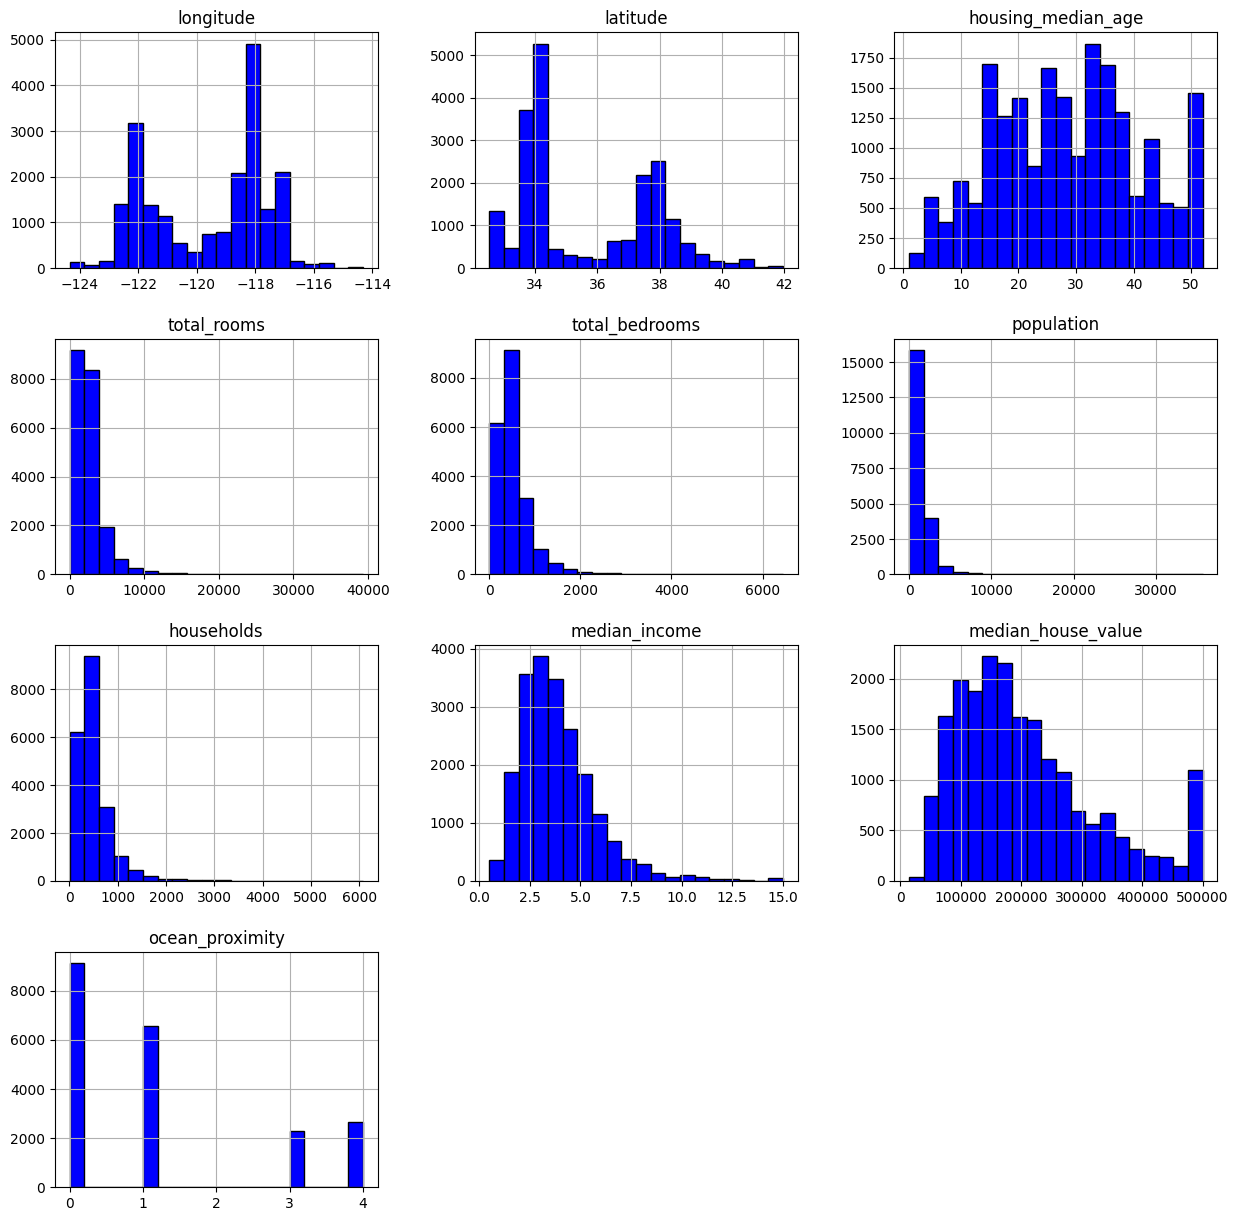

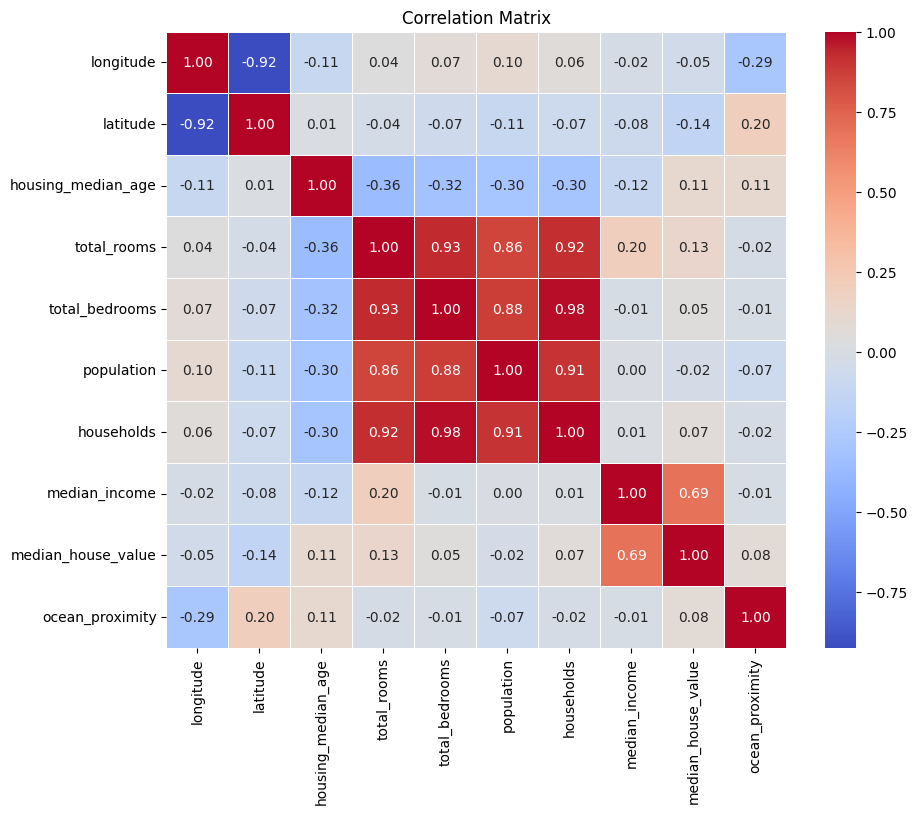


Correlation with Target (median_house_value):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
ocean_proximity       0.081750
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


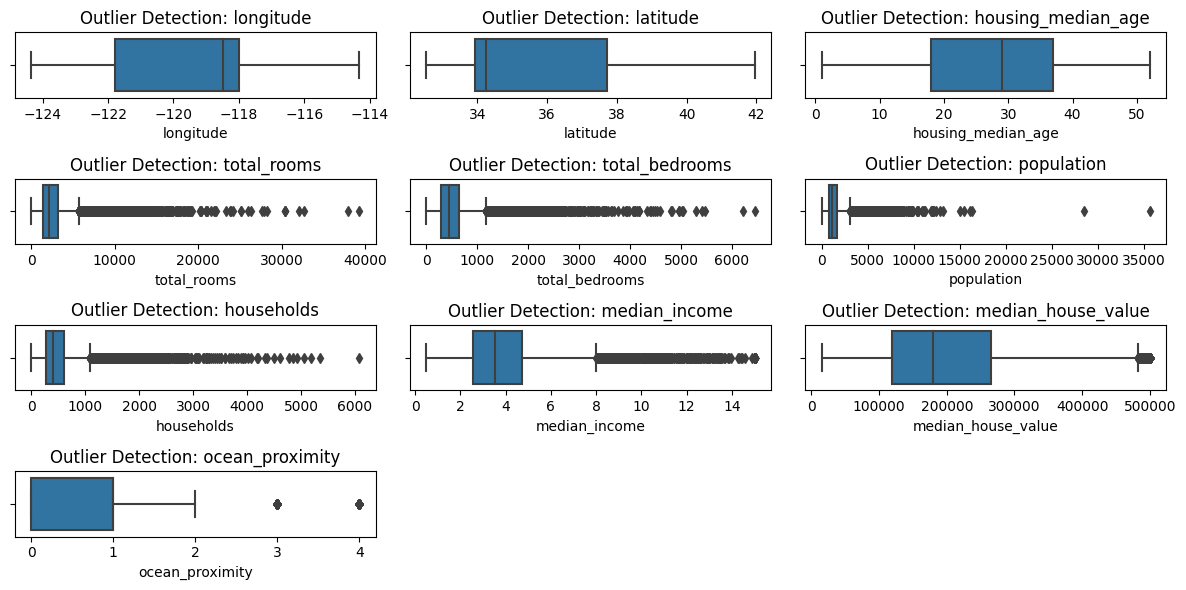

In [159]:
class AutoEDA:
    def __init__(self, df):
        """Initialize the class with a DataFrame."""
        self.df = df
        self._encode_categorical_columns()

    def _encode_categorical_columns(self):
        """Automatically encode categorical columns to numeric using Label Encoding."""
        categorical_cols = self.df.select_dtypes(include=['object']).columns
        self.label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col])
            self.label_encoders[col] = le  # Store the encoder for future reference if needed
    
    def missing_values(self):
        """Display missing values count and percentage."""
        missing_data = self.df.isnull().sum()
        missing_percentage = (self.df.isnull().mean() * 100).round(2)
        missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percentage})
        return missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

    def summary_stats(self):
        """Show summary statistics of numeric columns."""
        return self.df.describe()

    def correlation_matrix(self):
        """Plot a correlation heatmap."""
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()

    def target_correlation(self, target):
        """Show correlation of all variables with the target variable."""
        correlations = self.df.corr()[target].sort_values(ascending=False)
        return correlations

    def plot_distributions(self):
        """Plot distributions for all numeric features."""
        numeric_cols = self.df.select_dtypes(include=['float64', 'int64']).columns
        self.df[numeric_cols].hist(figsize=(15, 15), bins=20, color='blue', edgecolor='black')
        plt.show()

    def outlier_detection(self):
        """Detect outliers using box plots."""
        numeric_cols = self.df.select_dtypes(include=['float64', 'int64']).columns
        plt.figure(figsize=(12, 6))
        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(len(numeric_cols)//3+1, 3, i)
            sns.boxplot(x=self.df[col])
            plt.title(f'Outlier Detection: {col}')
        plt.tight_layout()
        plt.show()

    def run_eda(self, target=None):
        """Run all EDA steps automatically."""
        print("Missing Values:")
        print(self.missing_values())
        print("\nSummary Statistics:")
        print(self.summary_stats())
        self.plot_distributions()
        self.correlation_matrix()
        if target:
            print(f"\nCorrelation with Target ({target}):")
            print(self.target_correlation(target))
        self.outlier_detection()

df1 = pd.read_csv('/kaggle/input/california-housing-prices/housing.csv')
eda = AutoEDA(df1)
eda.run_eda(target='median_house_value')

In [160]:
df1.dropna(inplace=True)

In [162]:
X = df1.drop(columns=['median_house_value'])
y = df1['median_house_value']
print(X.shape)
print(y.shape)

(20433, 9)
(20433,)


In [163]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=113)

In [164]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [165]:
model = Sequential()
# Add layers
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer
model.add(Dense(64, activation='relu'))  # Second hidden layer
model.add(Dense(1, activation='linear'))  # Output layer

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [166]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

In [173]:
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=5, batch_size=10)

Epoch 1/5
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6614127104.0000 - mae: 58147.8359 - val_loss: 6350179328.0000 - val_mae: 57197.5352
Epoch 2/5
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5616936448.0000 - mae: 54485.2109 - val_loss: 5815298048.0000 - val_mae: 55565.9648
Epoch 3/5
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5536363008.0000 - mae: 53921.5742 - val_loss: 5482117632.0000 - val_mae: 54104.8750
Epoch 4/5
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5025117696.0000 - mae: 51923.8555 - val_loss: 5260227584.0000 - val_mae: 53130.6328
Epoch 5/5
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5147209216.0000 - mae: 51983.4062 - val_loss: 5114815488.0000 - val_mae: 52038.5078


In [172]:
y_pred = model.predict(X_test_scaled)
r2_score(y_test, y_pred)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.5173648043522648

In [168]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MAE: {test_mae}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6707156992.0000 - mae: 58131.1602
Test MAE: 57999.21484375


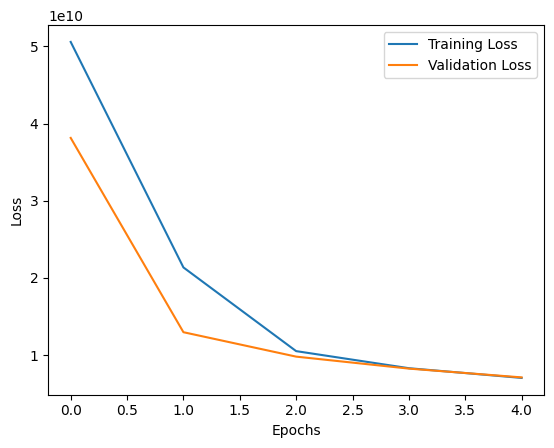

In [169]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [170]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,597 (57.02 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,732 (38.02 KB)

In [171]:
# from sklearn.metrics import r2_score
 
 
# df = pd.read_csv('/kaggle/input/california-housing-prices/housing.csv')
# df.dropna(inplace=True)
 
# # Step 4: Encode Categorical Data
# label_encoder = LabelEncoder()
# df['ocean_proximity'] = label_encoder.fit_transform(df['ocean_proximity'])
 
# # Step 5: Split the Data into Features (X) and Target (y)
# X = df.drop('median_house_value', axis=1).values  # Features
# y = df['median_house_value'].values  # Target
 
 
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
 
# model = Sequential()
# model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=32, activation='relu'))
# model.add(Dense(units=1))
 
 
# model.compile(optimizer='adam', loss='mean_squared_error')
# model.fit(X_train, y_train, epochs=10, batch_size=10, validation_split=0.2)
 
 
# y_pred = model.predict(X_test)
# r2_score(y_test, y_pred)